<a href="https://colab.research.google.com/github/KOS-noise/PyTorch-LLM-AI/blob/main/%EC%B1%95%ED%84%B02_%EC%BB%B4%ED%93%A8%ED%84%B0%EB%B9%84%EC%A0%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms  # ✅ 수정
from torch.utils.data import DataLoader

# 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 모델 정의
class FashionMNISTModel(nn.Module):
    def __init__(self):
        super(FashionMNISTModel, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = FashionMNISTModel()

# 손실 함수와 옵티마이저 정의
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters())  # ✅ 수정

# 모델 훈련 함수
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # 예측과 손실 계산
        pred = model(X)
        loss = loss_fn(pred, y)

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"손실: {loss:>7f} [{current:>5d} / {size:>5d}]")  # ✅ 수정

# 훈련 실행
epochs = 5
for t in range(epochs):
    print(f"에폭 {t+1}\n---------------------------")
    train(train_loader, model, loss_function, optimizer)
print("완료!")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.56MB/s]


에폭 1
---------------------------
손실: 2.304616 [    0 / 60000]
손실: 0.714065 [ 6400 / 60000]
손실: 0.543483 [12800 / 60000]
손실: 0.593132 [19200 / 60000]
손실: 0.375664 [25600 / 60000]
손실: 0.409475 [32000 / 60000]
손실: 0.471359 [38400 / 60000]
손실: 0.501737 [44800 / 60000]
손실: 0.487754 [51200 / 60000]
손실: 0.404444 [57600 / 60000]
에폭 2
---------------------------
손실: 0.582440 [    0 / 60000]
손실: 0.409835 [ 6400 / 60000]
손실: 0.519628 [12800 / 60000]
손실: 0.425939 [19200 / 60000]
손실: 0.563821 [25600 / 60000]
손실: 0.368570 [32000 / 60000]
손실: 0.245541 [38400 / 60000]
손실: 0.350223 [44800 / 60000]
손실: 0.440554 [51200 / 60000]
손실: 0.352549 [57600 / 60000]
에폭 3
---------------------------
손실: 0.344956 [    0 / 60000]
손실: 0.435821 [ 6400 / 60000]
손실: 0.310283 [12800 / 60000]
손실: 0.292235 [19200 / 60000]
손실: 0.437835 [25600 / 60000]
손실: 0.320127 [32000 / 60000]
손실: 0.308794 [38400 / 60000]
손실: 0.419633 [44800 / 60000]
손실: 0.343583 [51200 / 60000]
손실: 0.747719 [57600 / 60000]
에폭 4
--------------------------

In [ ]:
# 모델 테스트 함수
def test(dataloader, model):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval() # 모델을 평가 모드로 지정함
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X, y in dataloader:
      pred = model(X)
      test_loss += loss_function(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size
  print(f"테스트 오차: \n 정확도: {(100*correct):>0.1f}%,\
          평균 손실: {test_loss:>8f} \n")

# 모델 평가
test(test_loader, model)

테스트 오차: 
 정확도: 86.4%,          평균 손실: 0.371699 



In [ ]:
# 정확도 계산 함수 (기존 코드 그대로 사용)
def get_accuracy(pred, labels):
    _, predictions = torch.max(pred, 1)
    correct = (predictions == labels).float().sum()
    accuracy = correct / labels.shape[0]
    return accuracy

# 수정된 모델 훈련 함수 (정확도 출력 추가)
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()

    # 평균 계산을 위한 누적 변수 초기화
    total_loss = 0
    total_accuracy = 0

    for batch, (X, y) in enumerate(dataloader):
        # 예측과 손실 계산
        pred = model(X)
        loss = loss_fn(pred, y)
        accuracy = get_accuracy(pred, y)

        # 🌟 누락되었던 역전파 및 가중치 업데이트 🌟
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 누적 변수에 현재 배치의 손실과 정확도 더하기
        total_loss += loss.item()
        total_accuracy += accuracy.item()

        # 100번 배치마다 로그 출력
        if batch % 100 == 0:
            current = batch * len(X)
            # 현재까지의 평균 손실과 정확도 계산 (batch는 0부터 시작하므로 +1)
            avg_loss = total_loss / (batch + 1)
            avg_accuracy = (total_accuracy / (batch + 1)) * 100

            print(f"배치 {batch:3d} | 평균 손실: {avg_loss:>7.4f} | 평균 정확도: {avg_accuracy:>5.2f}% [{current:>5d}/{size:>5d}]")

        # 훈련 실행
epochs = 5
for t in range(epochs):
    print(f"에폭 {t+1}\n---------------------------")
    # 위에서 정의한 train 함수를 여기서 실제로 부릅니다!
    train(train_loader, model, loss_function, optimizer)
print("완료!")

에폭 1
---------------------------
배치   0 | 평균 손실:  0.2745 | 평균 정확도: 87.50% [    0/60000]
배치 100 | 평균 손실:  0.2873 | 평균 정확도: 89.36% [ 6400/60000]
배치 200 | 평균 손실:  0.2885 | 평균 정확도: 89.27% [12800/60000]
배치 300 | 평균 손실:  0.2907 | 평균 정확도: 89.20% [19200/60000]
배치 400 | 평균 손실:  0.2957 | 평균 정확도: 89.11% [25600/60000]
배치 500 | 평균 손실:  0.2964 | 평균 정확도: 89.13% [32000/60000]
배치 600 | 평균 손실:  0.2963 | 평균 정확도: 89.13% [38400/60000]
배치 700 | 평균 손실:  0.2972 | 평균 정확도: 89.09% [44800/60000]
배치 800 | 평균 손실:  0.2985 | 평균 정확도: 89.11% [51200/60000]
배치 900 | 평균 손실:  0.2957 | 평균 정확도: 89.14% [57600/60000]
에폭 2
---------------------------
배치   0 | 평균 손실:  0.1891 | 평균 정확도: 92.19% [    0/60000]
배치 100 | 평균 손실:  0.3013 | 평균 정확도: 88.75% [ 6400/60000]
배치 200 | 평균 손실:  0.2824 | 평균 정확도: 89.68% [12800/60000]
배치 300 | 평균 손실:  0.2831 | 평균 정확도: 89.74% [19200/60000]
배치 400 | 평균 손실:  0.2840 | 평균 정확도: 89.66% [25600/60000]
배치 500 | 평균 손실:  0.2812 | 평균 정확도: 89.77% [32000/60000]
배치 600 | 평균 손실:  0.2837 | 평균 정확도: 89.61% [38400/60000]

tensor([[ -1.3247, -11.9116,  -2.9649,  -4.9966,  -4.7849,  -9.2472,  -0.4081,
         -11.4183,  -6.0389, -10.3010]])


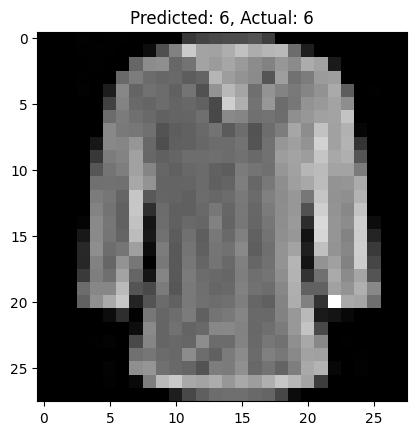

모델의 예측 6, 실제 레이블: 6.


In [ ]:
import matplotlib.pyplot as plt

def predict_single_image(image, label, model):
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 모델이 기대하는 배치 차원을 추가합니다.
    image = image.unsqueeze(0)

    with torch.no_grad():
        prediction = model(image)

        print(prediction)
        predicted_label = prediction.argmax(1).item()

    # 이미지와 예측 결과를 출력합니다.
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f'Predicted: {predicted_label}, Actual: {label}')
    plt.show()

    return predicted_label

# 테스트 세트에 있는 이미지 하나를 선택합니다.
image, label = test_dataset[4]  # 인덱스를 바꾸어 다른 이미지로 테스트해 보세요.

# 선택한 이미지의 레이블을 예측합니다.
predicted_label = predict_single_image(image, label, model)
print(f"모델의 예측 {predicted_label}, 실제 레이블: {label}.")

In [ ]:
if batch % 100 == 0:
  current = batch * len(X)
  avg_loss = total_loss / (batch + 1)
  avg_accuracy = total_accuracy / (batch + 1) * 100
  print(f"배치 {batch}, 손실: {avg_loss:>7f}, 정확도: {avg_accuracy:>0.2f}% [{current:>5d} / {size:>5d}]")

#조기 종료 조건
if avg_accuracy >= 95:
  print("95% 정확도에 도달했으므로 훈련을 중지합니다.")
  return True # 훈련 중지

NameError: name 'batch' is not defined